# AC Optimal Power Flow with `difflow_power`

Every number a grid study produces is really a question about a derivative.
*What does another megawatt at this bus cost?* is `d(cost)/d(load)`.
*Which line rating is worth raising?* is a shadow price.
*What does re-tapping this transformer do to the voltage profile?* is `d(V)/d(tap)`.

Classical power-system tools answer these with hand-derived sensitivity factors —
generation shift factors, loss factors, the reduced Jacobian — each derived,
coded and validated separately from the model they came from, and each able to
drift out of step with it.

This notebook works through the alternative: a differentiable model, where those
factors *are* the derivatives, taken through the implicit function theorem at the
converged solution. We will

1. solve a power flow and check it against MATPOWER,
2. solve the AC optimal power flow and read its prices,
3. verify that the prices really are prices, two independent ways,
4. watch congestion separate the prices on the PJM 5-bus case,
5. screen every single-line contingency with one matrix product,
6. approach the loadability limit and watch the Jacobian go singular,
7. and solve a distribution feeder sequentially, as a flowsheet.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import difflow_power as dp

print(dp.cases.case9().summary())

case9 (WSCC 9-bus): 9 buses (1 slack, 2 PV, 6 PQ), 9 branches (0 transformers, 9 rated), 3 generators (820 MW capacity), 3 loads (315.0 MW + 115.0 MVAr), 1 loops, base 100 MVA


## 1. A power flow, and why it is checked against MATPOWER

The WSCC 9-bus case is the field's standard benchmark: three machines, each tied
to the network by a single branch (the step-up transformers of the original case,
modelled in the case file as plain lines at unit tap, hence "0 transformers"
above), three loads, one loop.

A self-consistent power flow implementation with the phase-shift sign backwards,
or the line charging halved twice, converges beautifully to the wrong numbers.
So the only check worth anything is against a published answer for the same case
file. MATPOWER's `runpf case9` gives `Pg = (71.955, 163, 85)` MW,
`Va2 = 9.6687°`, and 4.9547 MW of losses.

In [2]:
net = dp.cases.case9()
pf = dp.solve_power_flow(net)
print(pf.summary())

print("\n  Pg (MW):    ", {k: round(v, 3) for k, v in pf.pg_mw.items()})
print("  Qg (MVAr):  ", {k: round(v, 3) for k, v in pf.qg_mvar.items()})
print("  Va2 (deg):  ", round(pf.va_degrees["2"], 4))
print("  losses (MW):", round(pf.losses_mw, 4))

case9 (WSCC 9-bus): converged in 5 Newton steps, max mismatch 1.05e-12 MW/MVAr; 320.0 MW generated for 315.0 MW load (4.95 MW loss); voltages 0.958 (9) to 1.003 (6); 0 limit violations

  Pg (MW):     {'g1': 71.955, 'g2': 163.0, 'g3': 85.0}
  Qg (MVAr):   {'g1': 24.069, 'g2': 14.46, 'g3': -3.649}
  Va2 (deg):   9.6687
  losses (MW): 4.9547


Newton-Raphson via `optimistix`, so the gradient of anything here with respect to
anything the residual depends on comes from the implicit function theorem at the
converged point. A gradient costs one linear solve however many Newton steps the
forward pass took, and it does not depend on the initial guess.

**A converged power flow is not a feasible operating point.** It solves the
equations and enforces no limit whatsoever. Load the case up and it will happily
return generators past their var capability and lines over their rating:

In [3]:
stressed = net.scaled_load(1.8)
res = dp.solve_power_flow(stressed)
print(res.summary())
for what, why in res.violations().items():
    print(f"  {what:12s} {why}")

case9 (WSCC 9-bus): converged in 6 Newton steps, max mismatch 7.36e-13 MW/MVAr; 580.3 MW generated for 567.0 MW load (13.26 MW loss); voltages 0.863 (9) to 1.000 (1); 4 limit violations
  vm_5         0.8942 pu below vm_min 0.9000
  vm_9         0.8625 pu below vm_min 0.9000
  pg_g1        332.26 MW above p_max 250.00
  rate_br1     146.5% of rating


That gap between "the equations hold" and "the limits hold" is exactly what an
optimal power flow exists to close. `verify.operating_report` reports the two
separately, so one is never mistaken for the other:

In [4]:
report = dp.operating_report(res.x, stressed)
print("solves the equations:", report.solved)
print("respects the limits: ", report.feasible)
print(report.summary())

solves the equations: True
respects the limits:  False
mismatch 1.33e-13 MW / 7.36e-13 MVAr; 2 voltage; 1 generator; 1 thermal (worst 147%)


## 2. The AC optimal power flow

$$\min_{V,\theta,P_g,Q_g} \sum_k c_k(P_{g,k})$$

subject to the same power flow equations, plus voltage limits, generator boxes
and thermal ratings — the constraints the power flow ignored.

This is a nonconvex NLP. The field solves it with a primal-dual interior-point
method (IPOPT, MATPOWER's MIPS, KNITRO); none of those is a JAX program, and
calling out to one would end the differentiability that is the point. So
`difflow_power.ipm` implements one in JAX.

MATPOWER's `runopf case9` optimum is **$5296.69/h**.

In [5]:
opf = dp.solve_acopf(net)
print(opf.summary())
print("\n  cost: $%.4f/h   (MATPOWER: 5296.69)" % opf.cost)
print("  dispatch (MW):", {k: round(v, 2) for k, v in opf.pg_mw.items()})
print("  power flow    :", {k: round(v, 2) for k, v in pf.pg_mw.items()})

case9 (WSCC 9-bus): converged in 19 interior-point iterations, cost $5296.69/h for 315.0 MW load (3.31 MW loss); LMP 24.03 to 25.00 $/MWh; 3 binding constraints (vm_1_max, vm_6_max, vm_8_max)

  cost: $5296.6862/h   (MATPOWER: 5296.69)
  dispatch (MW): {'g1': 89.8, 'g2': 134.32, 'g3': 94.19}
  power flow    : {'g1': 71.95, 'g2': 163.0, 'g3': 85.0}


The optimiser has moved every unit. It costs less than the scheduled operating
point, and it is feasible by construction — every limit it carried holds at the
answer. The scheduled point happens to be feasible too, but nothing in the power
flow guaranteed that, as the stressed case above showed.

In [6]:
layout = dp.power_state_layout(net)
scheduled = float(dp.opf.generation_cost(pf.x, net, layout))
print(f"scheduled dispatch: ${scheduled:.2f}/h")
print(f"optimal dispatch:   ${opf.cost:.2f}/h")
print(f"saving:             ${scheduled - opf.cost:.2f}/h")
print("\nfeasible:", dp.operating_report(opf.x, net, opf.layout).feasible)
print("binding: ", {k: round(v, 1) for k, v in opf.binding().items()})

scheduled dispatch: $5438.32/h
optimal dispatch:   $5296.69/h
saving:             $141.64/h

feasible: True
binding:  {'vm_1_max': 8.2, 'vm_6_max': 75.4, 'vm_8_max': 77.6}


### How the interior-point method gets there

Slacks turn the inequalities into $h(x) + s = 0$ with a log barrier keeping
$s>0$, and each iteration is a Newton step on the perturbed KKT conditions.
Three things make it converge on a real nonconvex case:

- **inertia correction** on a Ruiz-equilibrated KKT matrix (inertia is invariant
  under diagonal congruence, and $\Sigma = z/s$ otherwise spans twelve decades
  near the solution and swamps any tolerance);
- **fraction to boundary**, capping the step so slacks stay interior;
- an **$\ell_1$ merit line search**, without which the full Newton step
  overshoots badly from a flat start.

The iteration log shows feasibility, stationarity and complementarity all driven
down, complementarity last, with $\mu$ following IPOPT's monotone schedule:

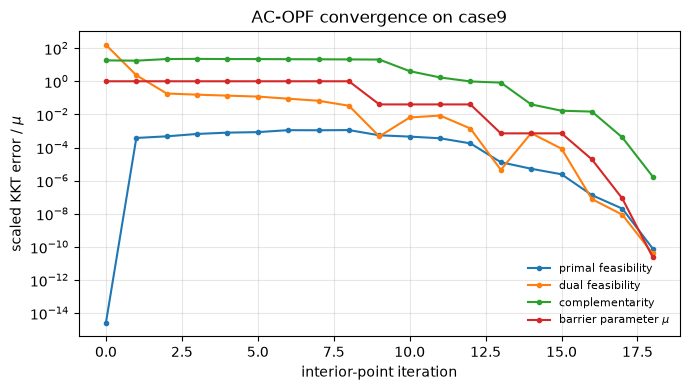

In [7]:
history = opf.ipm.history
fig, ax = plt.subplots(figsize=(7, 4))
for key, label in [
    ("feasibility", "primal feasibility"),
    ("stationarity", "dual feasibility"),
    ("complementarity", "complementarity"),
    ("mu", r"barrier parameter $\mu$"),
]:
    ax.semilogy([h[key] + 1e-18 for h in history], marker="o", ms=3, label=label)
ax.set_xlabel("interior-point iteration")
ax.set_ylabel(r"scaled KKT error / $\mu$")
ax.set_title("AC-OPF convergence on case9")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()

## 3. Prices, and whether they really are prices

The multiplier on a bus's real-power balance **is** its locational marginal
price. With the balance written as $(P_g - P_d) - P_{inj}(V) = 0$, adding a MW at
bus $i$ perturbs row $i$ by $-1$, so

$$\text{LMP}_i = -\lambda_i / \text{base MVA} \quad [\$/\text{MWh}]$$

That is an assertion about what a number *means*, and it is exactly the kind of
assertion that is easy to get wrong by a sign or a scale factor. So check it
independently: differentiate the **optimal cost** with respect to demand through
the KKT system, and compare. The envelope theorem says the two must agree.

In [8]:
prices = opf.lmp_mw
errors = opf.check_prices()

print(" bus   LMP ($/MWh)   |multiplier - autodiff|")
for bus in net.bus_ids:
    print(f"  {bus:3s}   {prices[bus]:8.4f}      {errors[bus]:.2e}")
print(f"\nlargest disagreement: {max(errors.values()):.2e} $/MWh")

 bus   LMP ($/MWh)   |multiplier - autodiff|
  1      24.7557      9.88e-13
  2      24.0345      3.91e-13
  3      24.0759      8.60e-13
  4      24.7559      6.32e-13
  5      24.9985      1.37e-12
  6      24.0759      1.01e-12
  7      24.2539      1.40e-12
  8      24.0345      1.06e-12
  9      24.9985      1.79e-12

largest disagreement: 1.79e-12 $/MWh


Agreement to ~1e-12 across every bus. Two completely different computations —
reading a Lagrange multiplier, and implicitly differentiating a converged KKT
system — landing on the same number.

Nothing is thermally congested here, but three upper voltage limits bind
(`vm_1_max`, `vm_6_max`, `vm_8_max`), and the prices spread by about 4%. How much
of that is losses? Relax the voltage limits and see:

In [9]:
relaxed = dp.solve_acopf(net, enforce_voltage=False)

def spread(lmp):
    return (max(lmp.values()) - min(lmp.values())) / min(lmp.values()) * 100

print(f"LMP spread, voltage limits enforced: {spread(opf.lmp_mw):.2f}%")
print(f"LMP spread, voltage limits relaxed:  {spread(relaxed.lmp_mw):.2f}%")
print("relaxed LMPs ($/MWh):", {k: round(v, 2) for k, v in relaxed.lmp_mw.items()})

LMP spread, voltage limits enforced: 4.01%
LMP spread, voltage limits relaxed:  0.46%
relaxed LMPs ($/MWh): {'1': 24.05, '2': 23.97, '3': 23.98, '4': 24.06, '5': 24.08, '6': 23.99, '7': 24.02, '8': 23.99, '9': 24.08}


Only about half a percent of the spread is the **loss component** — the fact
that a MW delivered far from the marginal unit costs more than a MW delivered
next to it. The rest is the price of holding voltage down at buses 1, 6 and 8.

We can see the loss effect from the power-flow side, as marginal loss factors:

In [10]:
factors = dp.loss_sensitivity(net)
print(" bus   d(loss)/d(load)")
for i, bus in enumerate(net.bus_ids):
    print(f"  {bus:3s}   {float(factors[i]):+.5f}")

 bus   d(loss)/d(load)
  1     +0.00000
  2     -0.04822
  3     -0.03927
  4     +0.00009
  5     +0.01069
  6     -0.03919
  7     -0.03414
  8     -0.04786
  9     +0.01009


The slack bus is exactly zero — load added there is served there, so nothing
moves. The **negative** entries are not a sign error: buses 2, 3, 6 and 8 sit beside
units holding a fixed schedule and exporting it across the network (and bus 7
sits between them), so load added there is consumed locally instead of being
wheeled, and total transport (and loss) falls. These factors are taken at the
scheduled power-flow point, not at the OPF dispatch.

## 4. Congestion: the PJM 5-bus case

`case9` has no binding thermal limit, so its prices separate only through losses
and voltage limits. The PJM 5-bus case is the standard teaching case for the
opposite: linear costs, so the merit order is unambiguous, and two rated lines,
one of which (4-5) is tight enough to bind. Expensive generation is forced
on behind the constraint, and the prices come apart.

In [11]:
pjm = dp.cases.case5()
congested = dp.solve_acopf(pjm)
uncongested = dp.solve_acopf(pjm, enforce_ratings=False)

print("with ratings:    $%.2f/h   (MATPOWER: 17551.89)" % congested.cost)
print("without ratings: $%.2f/h" % uncongested.cost)
print("congestion cost: $%.2f/h\n" % (congested.cost - uncongested.cost))

print(" bus   congested   uncongested   offer of the local unit")
offers = {}
for g in pjm.generators.values():
    offers.setdefault(g.bus, []).append(g.cost[-2])
for bus in pjm.bus_ids:
    offer = "/".join(f"{c:.0f}" for c in offers.get(bus, [])) or "-"
    print(f"  {bus:3s}   {congested.lmp_mw[bus]:8.2f}    "
          f"{uncongested.lmp_mw[bus]:8.2f}      {offer:>6s}")

with ratings:    $17551.89/h   (MATPOWER: 17551.89)
without ratings: $14997.04/h
congestion cost: $2554.85/h

 bus   congested   uncongested   offer of the local unit
  1        16.94       29.55       14/15
  2        26.55       29.99           -
  3        30.00       30.00          30
  4        39.71       29.86          40
  5        10.00       29.45          10


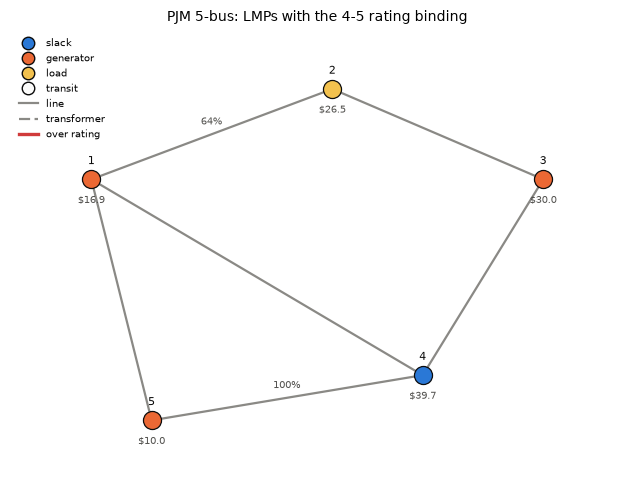

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
dp.draw_network(
    pjm,
    pos={"1": (0, 1), "2": (1.6, 1.6), "3": (3.0, 1.0),
         "4": (2.2, -0.3), "5": (0.4, -0.6)},
    prices=congested.lmp_mw,
    loading={
        a: congested.branch_mva[a] / br.rate_mva
        for a, br in pjm.branches.items() if br.rate_mva is not None
    },
    ax=ax,
    title="PJM 5-bus: LMPs with the 4-5 rating binding",
)
dp.draw_legend(ax)
plt.tight_layout()

Bus 5 hosts the \$10/MWh unit and prices at its offer; bus 4, behind the binding
tie, prices at nearly \$40/MWh. The spread is the congestion rent, and it is the
whole reason to run an optimal power flow rather than a merit-order dispatch.

`binding()` names each constraint and prices it — the shadow price is what the
objective would improve by per unit of relaxation, in $/h per unit of the
constraint *as posed*. That is $/h per pu (100 MW) for a generator bound, so
`pg_g1_max` is the unit's rent over its offer, and $/h per pu² of $|S|^2$ for a
rating, because thermal limits are written on $|S|^2$. Raising the 4-5 rating by
one MVA is therefore worth about $1277 \times 2 \times 2.4 / 100 \approx$ \$61/h.
`rate_to_5` means the to-end of branch index 5, i.e. `br6` (4-5), not bus 5:

In [13]:
for name, price in sorted(
    congested.binding().items(), key=lambda kv: -kv[1]
):
    print(f"  {name:20s} {price:10.2f}")

  rate_to_5               1277.31
  pg_g1_max                293.51
  pg_g2_max                193.51
  vm_3_max                 156.90
  qg_g1_max                 35.70
  qg_g2_max                 35.70
  pg_g4_min                 28.79
  qg_g3_max                 10.51


## 5. Contingency screening with PTDF and LODF

The DC approximation — negligible resistance, flat voltages, small angles — makes
the model linear, so the map from injections to flows is a constant matrix.
That is what makes screening every single-line outage a matrix product instead of
$n$ power flows.

`LODF[l, k]` is the fraction of branch $k$'s pre-outage flow that lands on branch
$l$ when $k$ trips.

In [14]:
base = dp.solve_dc_power_flow(pjm)
after = dp.contingency_flows(pjm, base.p_from)
rates = pjm.branch_rate_array_pu(default=jnp.inf)

print("outage ->     resulting loading of each branch (% of rating)")
print("            " + "".join(f"{a:>9s}" for a in pjm.branch_ids))
for k, outaged in enumerate(pjm.branch_ids):
    loadings = jnp.abs(after[:, k]) / rates * 100.0
    cells = "".join(
        "        -" if not jnp.isfinite(rates[i])
        else f"{float(loadings[i]):8.0f}%"
        for i in range(pjm.n_branch)
    )
    print(f"  {outaged:>8s}  {cells}")

outage ->     resulting loading of each branch (% of rating)
                  br1      br2      br3      br4      br5      br6
       br1         0%        -        -        -        -     148%
       br2        79%        -        -        -        -     151%
       br3        45%        -        -        -        -     194%
       br4        75%        -        -        -        -      90%
       br5        69%        -        -        -        -      95%
       br6        81%        -        -        -        -       0%


A branch whose outage would **island** the network has an undefined column,
returned as `nan` rather than as a large finite number — a screening loop must
never mistake a disconnection for a manageable overload. `case9`'s three generator
connections, each the only link from a machine bus, are exactly that case:

In [15]:
factors = dp.lodf(net)
islanding = [
    net.branch_ids[i] for i in range(net.n_branch)
    if bool(jnp.isnan(jnp.diag(factors)[i]))
]
print("outages that island case9:", islanding)
print("endpoints:", [(b, net.branches[b].from_bus, net.branches[b].to_bus)
                    for b in islanding])

outages that island case9: ['br1', 'br4', 'br7']
endpoints: [('br1', '1', '4'), ('br4', '3', '6'), ('br7', '8', '2')]


## 6. Approaching the loadability limit

Load a network up and its power flow Jacobian approaches singularity. That is
what the nose of a P-V curve *is*: the point where the solution ceases to exist,
rather than merely becoming poor. The smallest singular value of the Jacobian is
the classical proximity-to-collapse index, and it is one `jax.jacobian` call here.

last multiplier at which Newton converged: 2.2


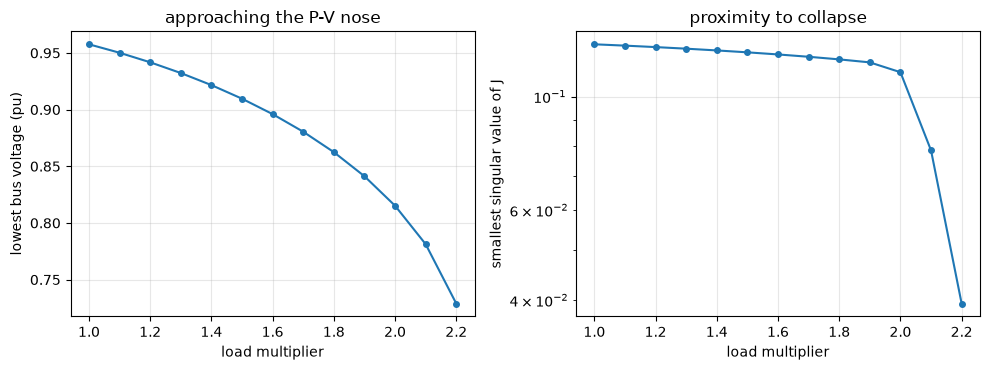

In [16]:
factors_tried, margins, voltages, converged = [], [], [], []
for factor in np.arange(1.0, 2.7, 0.1):
    loaded = net.scaled_load(float(factor))
    result = dp.solve_power_flow(loaded, max_steps=40)
    factors_tried.append(float(factor))
    converged.append(result.converged)
    margins.append(dp.voltage_stability_margin(result.x, loaded))
    voltages.append(min(result.vm.values()))

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))
ok = np.array(converged)
left.plot(np.array(factors_tried)[ok], np.array(voltages)[ok], "o-", ms=4)
left.set_xlabel("load multiplier"); left.set_ylabel("lowest bus voltage (pu)")
left.set_title("approaching the P-V nose"); left.grid(alpha=0.3)
right.semilogy(np.array(factors_tried)[ok], np.array(margins)[ok], "o-", ms=4)
right.set_xlabel("load multiplier")
right.set_ylabel("smallest singular value of J")
right.set_title("proximity to collapse"); right.grid(alpha=0.3)
plt.tight_layout()

last = max(f for f, c in zip(factors_tried, converged) if c)
print(f"last multiplier at which Newton converged: {last:.1f}")

## 7. A distribution feeder, solved as a flowsheet

Newton on the full system is the right method for a meshed transmission network
and more than a distribution feeder needs: a feeder has a high R/X ratio, which
breaks the P-θ / Q-V decoupling that fast-decoupled load flow relies on, and it is
radial, which makes a far cheaper method than full Newton available.

That method is the **backward/forward sweep**, and it is genuinely a
sequential-modular flowsheet solve — units in a topological schedule with one
tear, iterated to a fixed point. The tear is the voltage profile.

1. *Backward:* at each bus, KCL gives the current into its parent branch as what
   its children and shunt did not take. One pass, no matrix.
2. *Forward:* the branch relation inverts for the child voltage given the
   parent's. One pass from the fixed slack voltage.

Iterating the two converges **linearly** — about two and a half passes per
decade of accuracy here, so many more iterations than Newton's five. It is still
much less work, because a pass is $O(n)$ with no Jacobian formed, factorised or
differentiated. And it is exact, not an approximation.

In [17]:
feeder = dp.cases.radial_feeder()
sweep = dp.RadialFeederFlowsheet(feeder)
streams = sweep.solve()
newton = dp.solve_power_flow(feeder)

passes = int(sweep.last_solve_stats["num_steps"])
print(f"sweep: {passes} passes to floating-point tolerance, "
      "no Jacobian ever formed")
print(f"Newton: {newton.num_steps} steps, each factorising a Jacobian\n")
print(" bus     sweep         Newton        difference")
for bus in feeder.bus_ids:
    a = float(streams[f"bus_{bus}"]["P"])
    b = newton.vm[bus]
    print(f"  {bus:4s}  {a:.12f}  {b:.12f}  {abs(a - b):.1e}")

sweep: 28 passes to floating-point tolerance, no Jacobian ever formed
Newton: 5 steps, each factorising a Jacobian

 bus     sweep         Newton        difference
  s     1.020000000000  1.020000000000  0.0e+00
  n1    0.998791417100  0.998791417099  5.1e-13
  n2    0.971598397835  0.971598397834  8.1e-13
  n3    0.948817891653  0.948817891652  9.4e-13
  n4    0.939592023122  0.939592023121  9.7e-13
  l1    0.965276290472  0.965276290471  8.2e-13
  l2    0.938357723589  0.938357723589  9.7e-13


Two entirely different algorithms — one walking a tree through unit-level
admittance blocks, one factorising a Jacobian of the packed residual vector —
agreeing to 1e-12 on every bus. That is a far stronger check than either could
give on its own.

And because the fixed point is solved by `optimistix`, the sweep is
differentiable too. The gradient of the feeder-head infeed (the power the
substation sends into the feeder) with respect to load at the far end is greater
than one: a megawatt delivered to the end of the feeder
costs the substation more than a megawatt, and the excess is the loss it causes.

In [18]:
pd_pu, qd_pu = feeder.load_arrays_pu()
infeed = sweep.make_objective_fn(lambda s: jnp.asarray(s["bus_s"]["F_P"]))
gradient = jax.grad(lambda p: infeed((p, qd_pu)))(pd_pu)

print(" bus   d(head infeed)/d(load)   marginal loss")
for i, bus in enumerate(feeder.bus_ids):
    if bus == feeder.slack_bus:
        print(f"  {bus:4s}      {float(gradient[i]):.5f}"
              "               -  (substation load is not carried by the feeder head)")
    else:
        print(f"  {bus:4s}      {float(gradient[i]):.5f}"
              f"               {float(gradient[i]) - 1.0:+.5f}")

 bus   d(head infeed)/d(load)   marginal loss
  s         0.00000               -  (substation load is not carried by the feeder head)
  n1        1.02962               +0.02962
  n2        1.07087               +0.07087
  n3        1.10891               +0.10891
  n4        1.12495               +0.12495
  l1        1.08155               +0.08155
  l2        1.12779               +0.12779


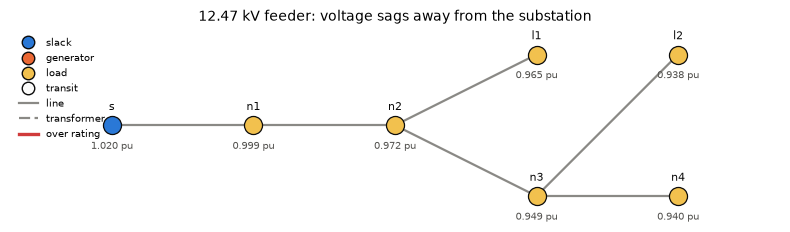

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
dp.draw_network(
    feeder,
    voltages={b: float(streams[f"bus_{b}"]["P"]) for b in feeder.bus_ids},
    ax=ax,
    title="12.47 kV feeder: voltage sags away from the substation",
)
dp.draw_legend(ax)
plt.tight_layout()

## What was differentiated, and what it bought

| question | answer |
|---|---|
| what does another MW here cost? | `opf.lmp_mw` — the equality multipliers |
| ...is that really the price? | `opf.check_prices()` — `jax.grad` of the optimum, agreeing to 1e-12 |
| how does the dispatch move with load? | `opf.solution_sensitivity()` (not shown here) |
| what is raising this rating worth? | `opf.binding()` — the shadow prices |
| what does a MW here cost in losses? | `dp.loss_sensitivity(net)` |
| what breaks if this line trips? | `dp.lodf(net)` |
| how close is this to collapse? | `dp.voltage_stability_margin(x, net)` |

The LMPs, their check, the dispatch sensitivity, the shadow prices and the loss
factors are derivatives of the same AC model, taken through the implicit function
theorem at the converged point — exact by construction, and unable to drift out of
step with the model they came from. LODF is the classical DC linearisation, exact
for the DC model and computed from the same network data, and the stability margin
is a property of the same power-flow Jacobian.

See `docs/unit-operations-power.md` for the full API, and
`src/difflow_power/README.md` for the design notes and the MATPOWER validation
table.